In [1]:
# Data manipulation
import stackstac
import rioxarray
import pandas as pd
import geopandas as gpd
import xarray as xr
from shapely.geometry import mapping, box

# I/O operations
import planetary_computer as pc
from pystac_client import Client as pystac_client

# Dask
#import dask
#import dask.delayed
#import dask.dataframe as dd
import dask_geopandas as dask_gpd
#from dask.distributed import Client as dask_client
from tqdm.notebook import tqdm

# Data Visualization
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [26]:
# Read file
train_df = gpd.read_file("data/train.csv")

# Convert geometries to WKT and GeoJSON 
train_df["geometry"] = gpd.GeoSeries.from_wkt(train_df["geometry"])
train_df["geojson"] = train_df["geometry"].apply(lambda x: mapping(x))

# Keep only columns needed for the search
#cols_to_keep = ["FarmID", "category", "SDate", "HDate", "geojson", "geometry"]
#train_df = train_df.loc[:, cols_to_keep]

In [3]:
# Build uniform 0.5° grid from Telanga boundaries
study_area = gpd.read_file("data/shp/telangana.shp")
min_x, min_y, max_x, max_y = [round(coord) for coord in study_area.total_bounds.tolist()]
cell_size = 0.5
x_cells = int((max_x - min_x) / cell_size)
y_cells = int((max_y - min_y) / cell_size)

polygons = []
tile_ids = []
for i in range(x_cells):
    for j in range(y_cells):

        x1 = min_x + i * cell_size
        y1 = min_y + j * cell_size

        poly = box(x1, y1, x1 + cell_size, y1 + cell_size)
        tile_id = f"{x1}_{y1 + cell_size}"
        
        polygons.append(poly)
        tile_ids.append(tile_id)

tiles = gpd.GeoDataFrame({"tile_id": tile_ids, "geometry": polygons}, crs="EPSG:4326")

In [4]:
# Join plots to 0.5° grid cells
train_gdf = gpd.GeoDataFrame(train_df, crs="EPSG:4326")
joined_gdf = train_gdf.sjoin(tiles)

In [5]:
# Load into a Dask dataframe and spatially partition by grid cell
unique_values = sorted(joined_gdf['tile_id'].unique())
divisions = unique_values + [unique_values[-1]]
joined_ddf = dask_gpd.from_geopandas(joined_gdf)
train_ddf = joined_ddf.set_index("tile_id", divisions=divisions)

In [6]:
train_ddf.map_partitions(lambda x: len(x)).compute()

0      18
1      27
2     724
3       1
4      53
5      90
6     449
7     361
8     156
9     220
10    724
11     64
12    662
13    110
14     57
15     36
16     23
17    125
18     10
19    774
20    600
21    552
22    597
23    117
24    136
25    418
26    201
27    607
28      9
dtype: int64

In [7]:
# Transfer parition 28 to separate dataframe
train_part_28 = train_ddf.get_partition(14)

In [8]:
# Sign into Microsoft planetary computer
stac_url = "https://planetarycomputer.microsoft.com/api/stac/v1"
sentinel2_client = pystac_client.open(
    stac_url,
    modifier=pc.sign_inplace
)

In [9]:
# Construct string of sow and harvest date
sow_date = train_part_28["SDate"].min().compute()[:10]
harvest_date = train_part_28["HDate"].max().compute()[:10]
sow_harvest = f"{sow_date}/{harvest_date}"

# Bounding box of spatial partition
partition_tile_id = train_part_28.divisions[0]
tile_geom  = tiles[tiles["tile_id"] == partition_tile_id]['geometry'].values[0]

# Search for Sentinel-2 imagery
search = sentinel2_client.search(
    collections=["sentinel-2-l2a"],
    bbox=list(tile_geom.bounds),
    datetime=sow_harvest,
)
items = list(search.items())

In [38]:
def normalized_difference(b1: xr.DataArray, b2: xr.DataArray, name: str):
    ndi = (b1 - b2) / (b1 + b2)
    ndi.name = name
    return ndi

def calc_evi(nir: xr.DataArray, red: xr.DataArray, blue: xr.DataArray):
    evi = 2.5 * (
        (nir - red) /
        (nir + 6 * red - 7.5 * blue + 1)
    )
    evi.name = "evi"
    return evi.drop_vars("band")

def calc_chlorophyll(red_edge: xr.DataArray, narrow_nir: xr.DataArray, name: str):
    chlorophyll = (narrow_nir - red_edge) / red_edge
    chlorophyll.name = name
    return chlorophyll.drop_vars("band")

def sanitize_stack(stack: xr.DataArray):
    desired_coords = ["time", "x", "y", "band", "year_month", "ndvi", "evi", "ndmi", "ndwi", "wet_chlorphyll", "canopy_chlorphyll"]
    slim_stack = stack.drop_vars(
        [coord for coord in stack.coords if coord not in desired_coords],
        errors="ignore"
    )
    return slim_stack

In [40]:
stacks = []
total_plots = len(train_part_28)

for idx, plot in tqdm(enumerate(train_part_28.iterrows()), total=len(train_part_28)):

    # Find spatial bounds 
    bounds = list(plot[1]["geometry"].bounds)
    bands = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "SCL"]
    plot_stack = stackstac.stack(
        items,
        bounds_latlon=bounds,
        assets=bands,
        epsg=4326,
        snap_bounds=False
    )

    # Find time bounds
    sow_date = plot[1]["SDate"][:10]
    harvest_date = plot[1]["HDate"][:10]
    sow_harvest = f"{sow_date}/{harvest_date}"

    # Filter stack to sow/harvest dates of plot
    plot_stack = plot_stack.sel(time=slice(sow_date, harvest_date)) 

    # Add FarmID
    plot_stack = plot_stack.assign_attrs(farm_id=plot[1]["FarmID"])

    # Scale raw values to reflectance
    blue = plot_stack.sel(band="B02") / 10000
    green = plot_stack.sel(band="B03") / 10000
    red = plot_stack.sel(band="B04") / 10000
    red_edge_5 = plot_stack.sel(band="B05") / 10000
    red_edge_7 = plot_stack.sel(band="B07") / 1000
    nir = plot_stack.sel(band="B08") / 10000
    narrow_nir = plot_stack.sel(band="B8A") / 10000
    swir = plot_stack.sel(band="B11") / 1000

    # Calculate vegetation indices
    plot_stack["ndvi"] = normalized_difference(nir, red, "ndvi")
    plot_stack["evi"] = calc_evi(nir, red, blue)
    plot_stack["ndwi"] = normalized_difference(green, nir, "ndwi")
    plot_stack["ndmi"] = normalized_difference(nir, swir, "ndmi")
    plot_stack["wet_chlorophyll"] = calc_chlorophyll(red_edge_5, narrow_nir, "wet_chlorophyll")
    plot_stack["canopy_chlorophyll"] = calc_chlorophyll(red_edge_7, narrow_nir, "canopy_chlorophyll")
    
    # Add year_month time coord for monthly aggregations
    plot_stack = plot_stack.assign_coords({"year_month": plot_stack["time"].dt.strftime("%Y-%m")})

    # Sanitize
    plot_stack = sanitize_stack(plot_stack)

    stacks.append(plot_stack)
    #zarr_path = f"zarrs/part_{14}/plot_{idx}_stack.zarr"
    #plot_stack.to_zarr(zarr_path, mode='w', compute=False)

  0%|          | 0/57 [00:00<?, ?it/s]

In [100]:
plot = stacks[21]
plot

<xarray.DataArray 'stackstac-2799044fb0d574b1ba771e7bba624d0b' (time: 126,
                                                                band: 9, y: 6,
                                                                x: 8)> Size: 435kB
dask.array<getitem, shape=(126, 9, 6, 8), dtype=float64, chunksize=(1, 1, 6, 8), chunktype=numpy.ndarray>
Coordinates:
  * time               (time) datetime64[ns] 1kB 2023-12-19T05:12:21.024000 ....
  * band               (band) <U3 108B 'B02' 'B03' 'B04' ... 'B8A' 'B11' 'SCL'
  * x                  (x) float64 64B 78.82 78.82 78.82 ... 78.82 78.82 78.82
  * y                  (y) float64 48B 16.91 16.91 16.91 16.91 16.91 16.91
    ndvi               (time, y, x) float64 48kB dask.array<chunksize=(1, 6, 8), meta=np.ndarray>
    evi                (time, y, x) float64 48kB dask.array<chunksize=(1, 6, 8), meta=np.ndarray>
    ndwi               (time, y, x) float64 48kB dask.array<chunksize=(1, 6, 8), meta=np.ndarray>
    ndmi               (time, y, x) float64 48kB dask.array<chunksize=(1, 6, 8), meta=np.ndarray>
    wet_chlorphyll     (time, y, x) float64 48kB dask.array<chunksize=(1, 6, 8), meta=np.ndarray>
    canopy_chlorphyll  (time, y, x) float64 48kB dask.array<chunksize=(1, 6, 8), meta=np.ndarray>
    year_month         (time) object 1kB '2023-12' '2023-12' ... '2024-11'
Attributes:
    spec:           RasterSpec(epsg=4326, bounds=[78.82346512251132, 16.90922...
    crs:            epsg:4326
    transform:      | 0.00, 0.00, 78.82|\n| 0.00,-0.00, 16.91|\n| 0.00, 0.00,...
    resolution_xy:  (np.float64(9.528029413274908e-05), np.float64(9.15963774...
    farm_id:        1328720

In [101]:
train_df[train_df["FarmID"] == plot.attrs["farm_id"]]

,FarmID,category,Crop,State,District,Sub-District,SDate,HDate,CropCoveredArea,CHeight,...,CLast,CTransp,IrriType,IrriSource,IrriCount,WaterCov,ExpYield,Season,geometry,geojson
1821,1328720,Healthy,Cotton,Telangana,Nalgonda,Chinthapally,2023-12-15 0:00:00,2024-11-03 0:00:00,67,116,...,Sorghum,Broadcasting,Drip,Groundwater,4,51,14,Rabi,"POLYGON ((78.82363 16.90981, 78.82419 16.90968...","{'type': 'Polygon', 'coordinates': (((78.82362..."


In [115]:
index = "canopy_chlorphyll"
monthly_index = plot[f"{index}"].groupby("year_month").mean()
#y = monthly_index.mean(dim=["x", "y"]).compute().to_numpy()

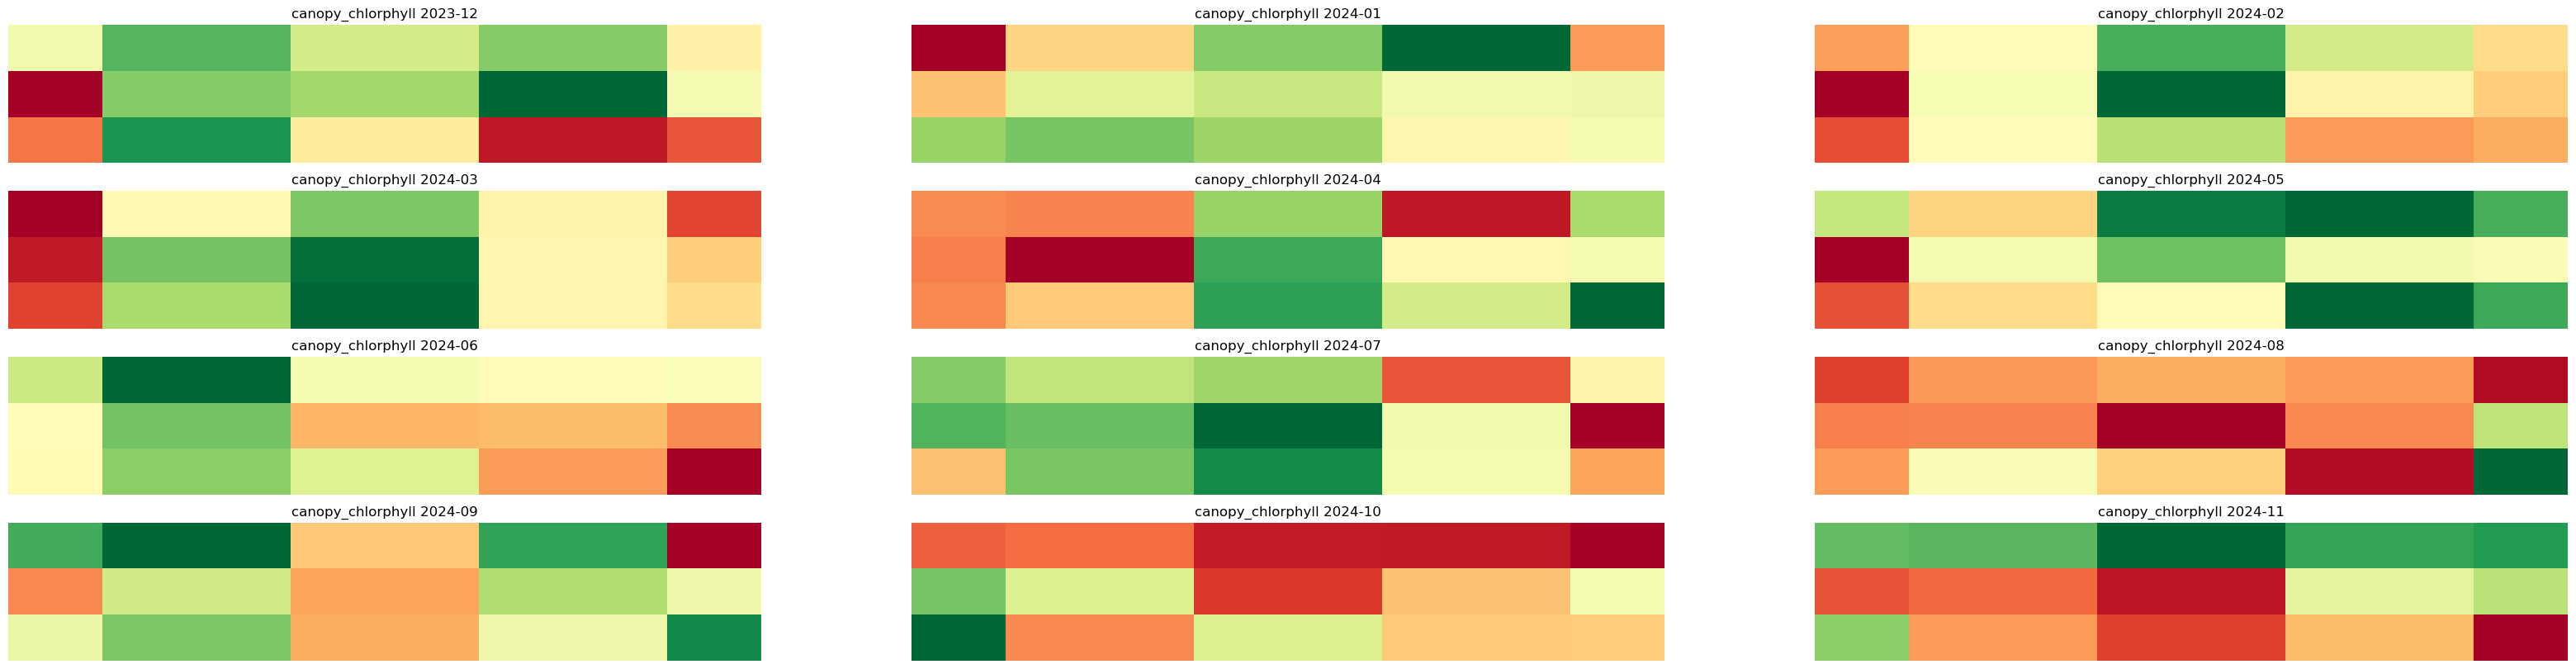

In [116]:
# Plot figure with 6 subplots
index_months = []
fig, axs = plt.subplots(int(len(y)/3), 3, figsize=(10*int(len(y)/3), 10))
for i, ax in enumerate(axs.flat):
    index_month = monthly_index[i].compute()
    index_months.append(index_month.to_numpy())
    index_month.plot(ax=ax, cmap='RdYlGn', add_colorbar=False)
    ax.set_title(f"{index} {monthly_index.year_month.values[i]}")
    ax.set_axis_off()

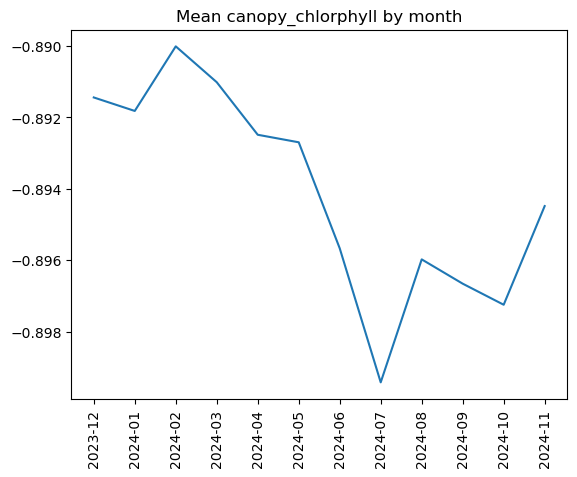

In [117]:
months = monthly_index["year_month"].values
means = [index_month.mean() for index_month in index_months]
# make x labels vertical
plt.xticks(rotation=90)
plt.title(f"Mean {index} by month")
plt.plot(months, means)

In [38]:
def calc_monthly_mean_index(plot: xr.DataArray, index):
    monthy_ndvi = plot_stack[index].groupby("year_month").mean()
    return monthy_index.mean(dim=["x", "y"]).compute()

In [27]:
# Get monthly mean NDVI of the plot
plot_stack = plot_stack.assign_coords({"year_month": plot_stack["time"].dt.strftime("%Y-%m")})
monthy_ndvi = plot_stack["ndvi"].groupby("year_month").mean()
monthly_means = monthy_ndvi.mean(dim=["x", "y"]).compute()

# Get monthly mean EVI of the plot
monthy_evi = plot_stack["evi"].groupby("year_month").mean()
monthly_evi_means = monthy_evi.mean(dim=["x", "y"]).compute()